# Case B — Calendar Events & College Football (DEAD)

**Client:** Drinking Excess Alcohol is Dangerous (DEAD). The weather
hypothesis (`caseb.ipynb` / `caseb_fixed.ipynb`) came back essentially null
once tested rigorously. This notebook tests a different, more actionable
hypothesis: **specific calendar occasions** (holidays, the Iowa State Fair,
and Iowa Hawkeyes / Iowa State Cyclones home football games) drive
higher-than-normal alcohol purchasing -- exactly the kind of pattern DEAD
could use to time targeted awareness campaigns.

Still linear regression only, as scoped. Starts from `liquor_2022_2026.parquet`
(built by `caseb_build_data.ipynb`'s approach / already present in this
project) rather than re-deriving it.

**A data-generating-process finding that reshapes this whole analysis** is
in section 1 below -- read that before the results, since it changes what
"event effect" actually means here.

In [1]:
import duckdb as db
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

con = db.connect()

## 1. This is wholesale ordering data, not point-of-sale data

Before building any event flags, a sanity check on which days of the week
`ordered_on` actually falls on -- and it's not evenly spread across the
week, which matters a lot for what follows.

In [2]:
dow = con.execute("""
    SELECT dayname(ordered_on) AS day_of_week, COUNT(*) AS n_line_items,
           SUM(sales_dollars) AS total_dollars
    FROM 'liquor_2022_2026.parquet'
    GROUP BY day_of_week
    ORDER BY total_dollars DESC
""").df()
dow

,day_of_week,n_line_items,total_dollars
0,Wednesday,2670104,4.710081e+08
1,Tuesday,2810014,4.492681e+08
2,Thursday,2233196,4.304227e+08
3,Monday,2355543,4.266218e+08
4,Friday,2798261,4.089151e+08
5,Sunday,212888,3.037531e+07
6,Saturday,167686,2.285110e+07


Saturday and Sunday combined are under 5% of total dollars, despite
being ~29% of calendar days. **`ordered_on` is the date a retailer's
wholesale order was placed/filled through Iowa's state-run liquor
distribution system -- not the date a customer bought a drink.** Consumers
buy alcohol every day of the week, obviously; this dataset just doesn't see
that, it sees when stores restock.

That reframes the question. A Saturday football game or a Sunday Super
Bowl can't show up as an `ordered_on` spike *on that day*, because
almost no wholesale ordering happens on weekends at all. What it *can* show
up as is elevated ordering in the **week containing or leading into** the
event, if retailers stock up in anticipation. So the unit of analysis below
is the **week**, and every "event effect" is really "was wholesale ordering
higher than normal in the week around this event" -- which is still exactly
what DEAD needs (that's the same week a campaign would need to run to be
in front of people before the event), just not the same as "did people
drink more that day."></br>

One consequence worth flagging up front: actual calendar holidays
(Thanksgiving, Christmas, New Year's Eve) can show up as **lower**
wholesale ordering in their week, because the distribution system itself
has fewer business days / holiday closures around them -- that's a
supply-side artifact, not evidence people drink less over the holidays.
The results below call this out explicitly rather than let it read as a
surprising finding.

## 2. Build weekly sales series (statewide, Iowa City, Ames)

Weekly (Monday-Sunday) totals sidestep the weekday-only ordering pattern
above. Built for three geographies: statewide, and the two biggest college
towns in the data (Iowa City / Hawkeyes, Ames / Cyclones) so the football
effect can be tested where it would actually show up rather than diluted
into a statewide average. The first and last calendar weeks in the data are
partial (the data starts mid-week and ends mid-week) and are dropped so
they don't read as artificially low-volume weeks.

In [3]:
def weekly_series(where_clause=""):
    query = f"""
        SELECT
            ordered_on,
            SUM(TRY_CAST(sales_bottles AS DOUBLE)) AS total_bottles,
            SUM(sales_dollars) AS total_dollars
        FROM 'liquor_2022_2026.parquet'
        {where_clause}
        GROUP BY ordered_on
    """
    daily = con.execute(query).df()
    daily["ordered_on"] = pd.to_datetime(daily["ordered_on"])
    daily["week"] = daily["ordered_on"].dt.to_period("W-SUN")  # Mon-Sun weeks

    weekly = daily.groupby("week")[["total_bottles", "total_dollars"]].sum().reset_index()
    weekly["week_start"] = weekly["week"].dt.start_time

    # drop partial boundary weeks
    return weekly[
        (weekly["week_start"] >= "2022-01-03") & (weekly["week_start"] <= "2026-08-24")
    ].reset_index(drop=True)


weekly_state = weekly_series()
weekly_iowacity = weekly_series("WHERE store_city = 'IOWA CITY'")
weekly_ames = weekly_series("WHERE store_city = 'AMES'")

print(f"{len(weekly_state)} weeks, {weekly_state['week_start'].min().date()} to {weekly_state['week_start'].max().date()}")
weekly_state.head()

243 weeks, 2022-01-03 to 2026-08-24


,week,total_bottles,total_dollars,week_start
0,2022-01-03/2022-01-09,483421.0,6654702.80,2022-01-03
1,2022-01-10/2022-01-16,485472.0,6397435.41,2022-01-10
2,2022-01-17/2022-01-23,499293.0,6654876.45,2022-01-17
3,2022-01-24/2022-01-30,516461.0,6812377.70,2022-01-24
4,2022-01-31/2022-02-06,532399.0,7604645.75,2022-01-31


## 3. Build the calendar-events table

Fixed-rule holidays (New Year's, St. Patrick's Day, Cinco de Mayo, July
4th, Halloween, Christmas) and calculated ones (Memorial Day, Labor Day,
Thanksgiving) are computed directly so this stays correct for any year
without re-typing dates. Three things aren't computable from a rule and
were looked up directly:

- **Super Bowl Sunday** (2022: Feb 13, 2023: Feb 12, 2024: Feb 11, 2025:
  Feb 9, 2026: Feb 8) -- [Super Bowl LVII](https://en.wikipedia.org/wiki/Super_Bowl_LVII),
  [Super Bowl LVIII](https://en.wikipedia.org/wiki/Super_Bowl_LVIII)
- **Iowa State Fair** dates each year -- [Iowa State Fair: Fair Dates & Attendance](https://www.iowastatefair.org/about/fair-dates-attendance)
- **Iowa Hawkeyes** (Kinnick Stadium, Iowa City) and **Iowa State Cyclones**
  (Jack Trice Stadium, Ames) home-game schedules, 2022-2025 seasons plus
  the confirmed 2026 opener/CyHawk dates -- from each season's Wikipedia
  team page (e.g. [2022 Iowa Hawkeyes](https://en.wikipedia.org/wiki/2022_Iowa_Hawkeyes_football_team),
  [2025 Iowa Hawkeyes](https://en.wikipedia.org/wiki/2025_Iowa_Hawkeyes_football_team))
  and official athletics schedule announcements. The Cy-Hawk rivalry game
  alternates host campus by year (Iowa City in 2022/2024, Ames in
  2023/2025/2026), which is reflected in which city's home-game list each
  date lands in.

**Not included:** RAGBRAI (the statewide bike ride) -- its route changes
towns every year, and pinning it to specific stores across 5 years reliably
would need a separate research pass. Worth a follow-up if this line of
analysis is useful.

In [4]:
def nth_weekday(year, month, weekday, n):
    """nth occurrence of `weekday` (Mon=0..Sun=6) in a given month."""
    first = pd.Timestamp(year=year, month=month, day=1)
    return first + pd.Timedelta(days=(weekday - first.weekday()) % 7 + 7 * (n - 1))


def last_weekday(year, month, weekday):
    """last occurrence of `weekday` in a given month."""
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
    return month_end - pd.Timedelta(days=(month_end.weekday() - weekday) % 7)


events = {}


def add_event(date, name):
    events.setdefault(pd.Timestamp(date), []).append(name)


# looked up directly (not computable from a fixed rule) -- see sources above
SUPER_BOWL_SUNDAY = {
    2022: "2022-02-13", 2023: "2023-02-12", 2024: "2024-02-11",
    2025: "2025-02-09", 2026: "2026-02-08",
}
IOWA_STATE_FAIR = {
    2022: ("2022-08-11", "2022-08-21"), 2023: ("2023-08-10", "2023-08-20"),
    2024: ("2024-08-08", "2024-08-18"), 2025: ("2025-08-07", "2025-08-17"),
    2026: ("2026-08-13", "2026-08-23"),
}
# Kinnick Stadium (Iowa City) home dates, 2022-2025 seasons + confirmed 2026 opener
HAWKEYES_HOME = {
    2022: ["2022-09-03", "2022-09-10", "2022-09-17", "2022-10-01", "2022-10-29", "2022-11-12", "2022-11-25"],
    2023: ["2023-09-02", "2023-09-16", "2023-09-30", "2023-10-07", "2023-10-21", "2023-11-11", "2023-11-18"],
    2024: ["2024-08-31", "2024-09-07", "2024-09-14", "2024-10-12", "2024-10-26", "2024-11-02", "2024-11-29"],
    2025: ["2025-08-30", "2025-09-13", "2025-09-27", "2025-10-18", "2025-10-25", "2025-11-08", "2025-11-22"],
    2026: ["2026-09-05"],  # opener only within this notebook's data window; CyHawk 9/12/26 is away for Iowa
}
# Jack Trice Stadium (Ames) home dates, 2022-2025 seasons + confirmed 2026 opener/CyHawk
CYCLONES_HOME = {
    2022: ["2022-09-03", "2022-09-17", "2022-09-24", "2022-10-08", "2022-10-29", "2022-11-05", "2022-11-19"],
    2023: ["2023-09-02", "2023-09-09", "2023-09-23", "2023-10-07", "2023-11-04", "2023-11-18"],
    2024: ["2024-08-31", "2024-09-21", "2024-10-05", "2024-10-19", "2024-11-02", "2024-11-09", "2024-11-16"],
    2025: ["2025-08-30", "2025-09-06", "2025-09-27", "2025-10-25", "2025-11-01", "2025-11-22"],
    2026: ["2026-09-05", "2026-09-12"],
}

for year in range(2022, 2027):
    add_event(f"{year}-01-01", "New Year's Day")
    add_event(f"{year}-12-31", "New Year's Eve")
    add_event(SUPER_BOWL_SUNDAY[year], "Super Bowl Sunday")
    add_event(f"{year}-03-17", "St. Patrick's Day")
    add_event(f"{year}-05-05", "Cinco de Mayo")
    add_event(last_weekday(year, 5, 0), "Memorial Day")
    add_event(f"{year}-07-04", "July 4th")
    add_event(nth_weekday(year, 9, 0, 1), "Labor Day")
    add_event(f"{year}-10-31", "Halloween")
    thanksgiving = nth_weekday(year, 11, 3, 4)
    add_event(thanksgiving, "Thanksgiving")
    add_event(thanksgiving - pd.Timedelta(days=1), "Thanksgiving")  # eve -> same week, same flag
    add_event(f"{year}-12-24", "Christmas")
    add_event(f"{year}-12-25", "Christmas")

    fair_start, fair_end = IOWA_STATE_FAIR[year]
    for day in pd.date_range(fair_start, fair_end):
        add_event(day, "Iowa State Fair")

for date in [d for season in HAWKEYES_HOME.values() for d in season]:
    add_event(date, "Hawkeyes Home Game")
for date in [d for season in CYCLONES_HOME.values() for d in season]:
    add_event(date, "Cyclones Home Game")

events_df = pd.DataFrame(
    [(date, names) for date, names in sorted(events.items())], columns=["date", "events"]
)
events_df["week"] = events_df["date"].dt.to_period("W-SUN")

EVENT_TYPES = [
    "New Year's Day", "New Year's Eve", "Super Bowl Sunday", "St. Patrick's Day",
    "Cinco de Mayo", "Memorial Day", "July 4th", "Labor Day", "Halloween",
    "Thanksgiving", "Christmas", "Iowa State Fair",
]

print(f"{len(events_df)} event-dates built, {events_df['week'].nunique()} distinct weeks touched")
events_df.head(10)

164 event-dates built, 95 distinct weeks touched


,date,events,week
0,2022-01-01,[New Year's Day],2021-12-27/2022-01-02
1,2022-02-13,[Super Bowl Sunday],2022-02-07/2022-02-13
2,2022-03-17,[St. Patrick's Day],2022-03-14/2022-03-20
3,2022-05-05,[Cinco de Mayo],2022-05-02/2022-05-08
4,2022-05-30,[Memorial Day],2022-05-30/2022-06-05
5,2022-07-04,[July 4th],2022-07-04/2022-07-10
6,2022-08-11,[Iowa State Fair],2022-08-08/2022-08-14
7,2022-08-12,[Iowa State Fair],2022-08-08/2022-08-14
8,2022-08-13,[Iowa State Fair],2022-08-08/2022-08-14
9,2022-08-14,[Iowa State Fair],2022-08-08/2022-08-14


## 4. Attach event flags to each weekly series, fit the regressions

One dummy per event type (1 if that week contains the event, else 0), plus
a `home_game` dummy for the Iowa City / Ames series specifically. Same
linear-regression setup as the weather notebook: a linear time trend `t` +
calendar-month fixed effects + the event dummies, on `log1p(total_bottles)`.

In [5]:
def build_week_flags(weekly_df, extra_event=None):
    out = weekly_df.copy()
    for event_type in EVENT_TYPES:
        weeks_with_event = set(
            events_df.loc[events_df["events"].apply(lambda lst: event_type in lst), "week"]
        )
        out[event_type] = out["week"].isin(weeks_with_event).astype(int)

    if extra_event is not None:
        event_name, col_name = extra_event
        weeks_with_event = set(
            events_df.loc[events_df["events"].apply(lambda lst: event_name in lst), "week"]
        )
        out[col_name] = out["week"].isin(weeks_with_event).astype(int)

    out["t"] = range(len(out))
    out["month"] = out["week_start"].dt.month
    out["log_bottles"] = np.log1p(out["total_bottles"])
    return out


weekly_state_f = build_week_flags(weekly_state)
weekly_iowacity_f = build_week_flags(weekly_iowacity, ("Hawkeyes Home Game", "home_game"))
weekly_ames_f = build_week_flags(weekly_ames, ("Cyclones Home Game", "home_game"))


def fit_event_model(df, event_cols):
    d = pd.get_dummies(df, columns=["month"], drop_first=True)
    month_cols = [c for c in d.columns if c.startswith("month_")]
    X = sm.add_constant(d[["t"] + month_cols + event_cols].astype(float))
    y = d["log_bottles"].astype(float)
    return sm.OLS(y, X).fit()


model_state = fit_event_model(weekly_state_f, EVENT_TYPES)
model_iowacity = fit_event_model(weekly_iowacity_f, EVENT_TYPES + ["home_game"])
model_ames = fit_event_model(weekly_ames_f, EVENT_TYPES + ["home_game"])

print(f"R-squared -- statewide: {model_state.rsquared:.3f}, "
      f"Iowa City: {model_iowacity.rsquared:.3f}, Ames: {model_ames.rsquared:.3f}")

R-squared -- statewide: 0.428, Iowa City: 0.332, Ames: 0.439


## 5. Results: estimated % lift in weekly wholesale ordering, per event

Coefficients converted from log points to a percent change
(`(exp(coef) - 1) * 100`) for interpretability -- e.g. +20% means that
event's week runs about 20% higher wholesale volume than a typical week,
holding month-of-year and the overall trend constant.

In [6]:
def event_results_table(model, event_cols):
    return pd.DataFrame({
        "pct_lift": (np.exp(model.params[event_cols]) - 1) * 100,
        "p_value": model.pvalues[event_cols],
    }).sort_values("pct_lift", ascending=False).round(2)


results_state = event_results_table(model_state, EVENT_TYPES)
results_iowacity = event_results_table(model_iowacity, EVENT_TYPES + ["home_game"])
results_ames = event_results_table(model_ames, EVENT_TYPES + ["home_game"])

print("=== Statewide ===")
print(results_state)

=== Statewide ===
                   pct_lift  p_value
Super Bowl Sunday     20.09     0.07
New Year's Day        13.70     0.41
Labor Day              6.20     0.59
Cinco de Mayo          4.41     0.66
Halloween              2.68     0.81
Memorial Day          -3.69     0.71
St. Patrick's Day     -4.07     0.68
Iowa State Fair       -5.54     0.50
Thanksgiving          -9.19     0.39
July 4th             -11.42     0.19
Christmas            -12.16     0.23
New Year's Eve       -23.31     0.10


In [7]:
print("=== Iowa City (Hawkeyes home games) ===")
print(results_iowacity)

=== Iowa City (Hawkeyes home games) ===
                   pct_lift  p_value
New Year's Day        54.38     0.07
Super Bowl Sunday     52.94     0.01
Labor Day             29.71     0.12
Cinco de Mayo         20.04     0.22
home_game             13.09     0.10
Memorial Day           5.54     0.73
Halloween              2.98     0.86
July 4th              -0.35     0.98
Christmas            -15.25     0.31
St. Patrick's Day    -18.44     0.18
Thanksgiving         -19.50     0.20
Iowa State Fair      -26.63     0.02
New Year's Eve       -35.47     0.07


In [8]:
print("=== Ames (Cyclones home games) ===")
print(results_ames)

=== Ames (Cyclones home games) ===
                   pct_lift  p_value
Cinco de Mayo         33.05     0.02
Super Bowl Sunday     15.80     0.25
New Year's Day        15.47     0.46
Labor Day             15.40     0.30
home_game              0.33     0.96
Halloween             -2.31     0.87
July 4th              -2.79     0.81
Christmas            -21.90     0.07
Iowa State Fair      -22.88     0.02
St. Patrick's Day    -23.16     0.04
Memorial Day         -26.75     0.02
Thanksgiving         -27.56     0.03
New Year's Eve       -41.82     0.01


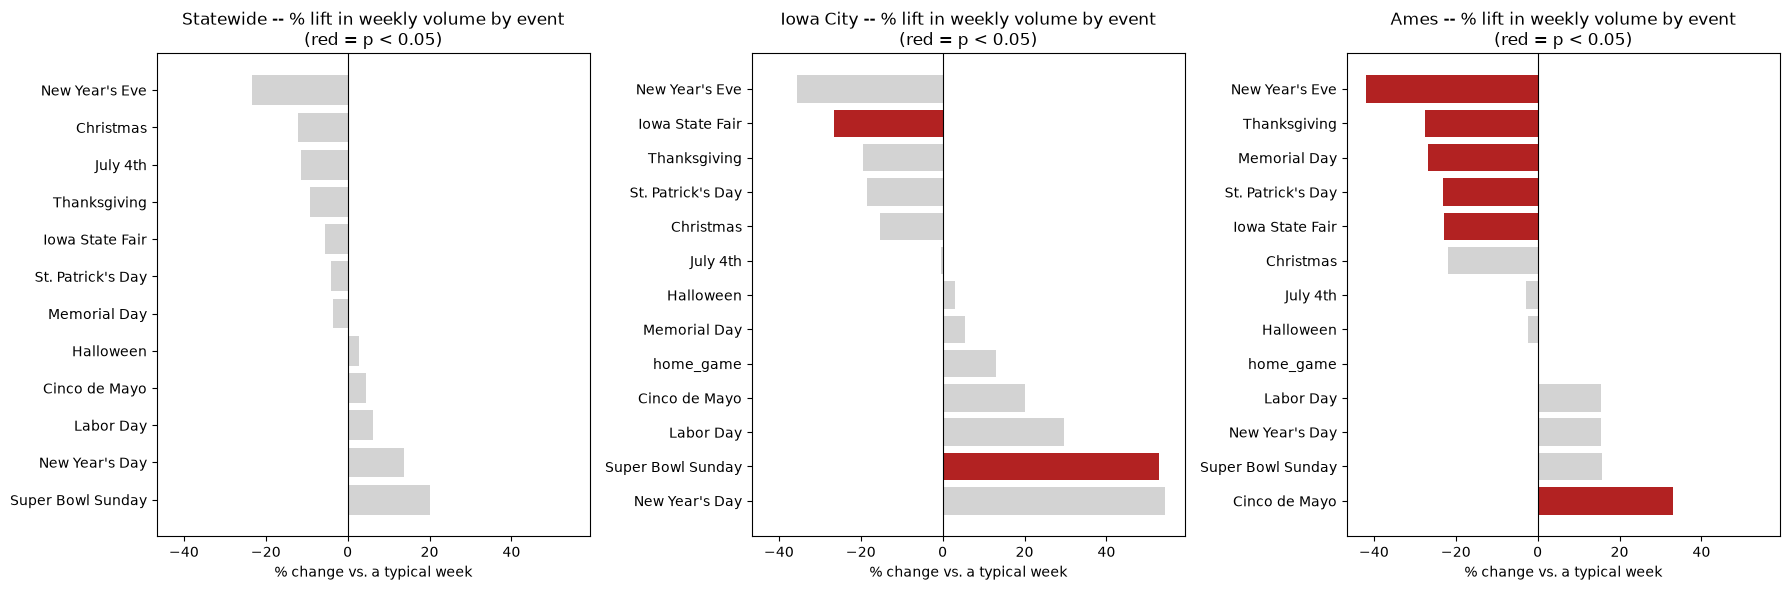

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

for ax, (results, title) in zip(
    axes,
    [(results_state, "Statewide"), (results_iowacity, "Iowa City"), (results_ames, "Ames")],
):
    colors = ["firebrick" if p < 0.05 else "lightgray" for p in results["p_value"]]
    ax.barh(results.index, results["pct_lift"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{title} -- % lift in weekly volume by event\n(red = p < 0.05)")
    ax.set_xlabel("% change vs. a typical week")

plt.tight_layout()
plt.show()

## 6. What this means for DEAD

**The cleanest, most statistically robust signal is Super Bowl Sunday**:
+20% statewide, +53% in Iowa City (p=0.01), and directionally positive in
Ames too. Unlike the actual calendar holidays, Super Bowl week doesn't
carry the "distribution system is partly closed" confound (it's a Sunday,
not a business holiday), so this reads as a genuine anticipatory restocking
effect -- exactly the kind of week a "watch the game responsibly" campaign
should run in.

**College football home games show a smaller, weaker effect than
expected**: +13% in Iowa City (p=0.10, borderline) and essentially flat in
Ames (p=0.96). Given jake_eda.ipynb's finding that university cities sell
noticeably more alcohol overall, this is a bit surprising -- most likely
explanation is that a single Saturday home game just doesn't move the needle
much against a college town's already-elevated baseline ordering, or that
whatever game-day effect exists shows up at the retail register on the day
itself (which this wholesale dataset can't see) rather than in restocking
patterns the week of.

**Actual holidays (Thanksgiving, Christmas, New Year's Eve) show up as
*lower* ordering, not higher** -- this is almost certainly the "state
distribution system has fewer business days around these dates" artifact
flagged in section 1, not evidence that less alcohol is consumed over the
holidays (final_eda.ipynb's complete-2025-year data shows the opposite:
Nov/Dec is the single biggest sales period of the year). Don't read these
as "drinking dips" -- read them as "this data can't see holiday-day
consumption directly."

**Iowa State Fair reads negative in Iowa City and Ames** (-27%, -23%,
both p<0.05) despite running for 10-11 days -- plausibly a substitution
effect (fair-week drinking happens at the fairgrounds in Des Moines/Polk
County, pulling some demand away from these two cities specifically) rather
than less drinking overall; worth checking the Polk County series
specifically as a follow-up before drawing a firm conclusion.

**Bottom line for campaign timing:** Super Bowl week is the one occasion in
this analysis that's both a large effect and statistically solid across
geographies -- the strongest, most defensible candidate for a timed DEAD
campaign. Everything else here is either too small, too uncertain, or
confounded by the wholesale-vs-retail timing issue to act on with the same
confidence without more targeted data (ideally point-of-sale/retail data
if DEAD can get access to it, which would let this same event-flag approach
be re-run without the "which week did the distributor deliver" confound
entirely).

One more timing wrinkle worth checking before trusting the holiday
estimates above -- see section 7.

## 7. Robustness check: does *pre-event* restocking lead time change these results?

Section 4's flags mark the calendar week that *contains* each event, on the
theory that anticipatory restocking happens sometime in that same
Monday-Sunday week. That assumption is fine for a mid-week event (a
Thursday holiday still leaves Mon-Wed of the same week for restocking), but
it can be wrong for an event that falls **on Monday itself**, since the
"week containing it" then consists almost entirely of the days *after* the
holiday, not before it. Worth checking which of the fixed holidays used
above are Monday-anchored.

In [10]:
holiday_dow = pd.DataFrame({
    "date": [d for d, names in events.items() if any(
        n in {"New Year's Day", "Memorial Day", "Labor Day", "July 4th", "Thanksgiving", "Christmas"}
        for n in names
    )],
})
holiday_dow["event"] = holiday_dow["date"].map(lambda d: next(
    n for n in events[d] if n in {"New Year's Day", "Memorial Day", "Labor Day", "July 4th", "Thanksgiving", "Christmas"}
))
holiday_dow["day_of_week"] = holiday_dow["date"].dt.day_name()
holiday_dow.sort_values(["event", "date"]).pivot(index="event", columns="date", values="day_of_week")

date,2022-01-01,2022-05-30,2022-07-04,2022-09-05,2022-11-23,2022-11-24,2022-12-24,2022-12-25,2023-01-01,2023-05-29,...,2025-12-24,2025-12-25,2026-01-01,2026-05-25,2026-07-04,2026-09-07,2026-11-25,2026-11-26,2026-12-24,2026-12-25
event,,,,,,,,,,,,,,,,,,,,,
Christmas,NaN,NaN,NaN,NaN,NaN,NaN,Saturday,Sunday,NaN,NaN,...,Wednesday,Thursday,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,Friday
July 4th,NaN,NaN,Monday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Saturday,NaN,NaN,NaN,NaN,NaN
Labor Day,NaN,NaN,NaN,Monday,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Monday,NaN,NaN,NaN,NaN
Memorial Day,NaN,Monday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,...,NaN,NaN,NaN,Monday,NaN,NaN,NaN,NaN,NaN,NaN
New Year's Day,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sunday,NaN,...,NaN,NaN,Thursday,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thanksgiving,NaN,NaN,NaN,NaN,Wednesday,Thursday,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Wednesday,Thursday,NaN,NaN


**Memorial Day and Labor Day are always Monday** -- by definition, they're
defined as "the Monday of ___ weekend." New Year's Day floats and lands on
a Monday in some years (2024) but not others. For those, the "week of"
flag used above is capturing mostly *after-the-long-weekend* days, and any
restocking done ahead of the holiday weekend would actually fall in the
**previous** Mon-Sun week -- exactly the opposite of what the flag intends
to test.

Two ways to fix this were tried against the statewide series: (1) **merge**
the event's week and the week immediately before into one flag, and (2)
**split** them into two separate dummies (`week of` / `week before`) so the
model can tell which one actually carries the lift.

In [11]:
def build_flags_variant(weekly_df, mode):
    out = weekly_df.copy()
    cols = []
    for event_type in EVENT_TYPES:
        weeks_with = set(events_df.loc[events_df["events"].apply(lambda lst: event_type in lst), "week"])
        if mode == "week_of":
            out[event_type] = out["week"].isin(weeks_with).astype(int)
            cols.append(event_type)
        elif mode == "merged_lead":
            widened = weeks_with | {w - 1 for w in weeks_with}
            out[event_type] = out["week"].isin(widened).astype(int)
            cols.append(event_type)
        elif mode == "split_lead":
            lead_only = {w - 1 for w in weeks_with} - weeks_with
            out[f"{event_type} (week of)"] = out["week"].isin(weeks_with).astype(int)
            out[f"{event_type} (week before)"] = out["week"].isin(lead_only).astype(int)
            cols += [f"{event_type} (week of)", f"{event_type} (week before)"]
    out["t"] = range(len(out))
    out["month"] = out["week_start"].dt.month
    out["log_bottles"] = np.log1p(out["total_bottles"])
    return out, cols


monday_holidays = ["Memorial Day", "Labor Day", "New Year's Day"]
variant_summary = {}

for mode in ["week_of", "merged_lead", "split_lead"]:
    df_variant, cols_variant = build_flags_variant(weekly_state, mode)
    model_variant = fit_event_model(df_variant, cols_variant)
    rows = [c for c in cols_variant if any(h in c for h in monday_holidays)]
    lift = (np.exp(model_variant.params[rows]) - 1) * 100
    pval = model_variant.pvalues[rows]
    variant_summary[mode] = pd.DataFrame({"pct_lift": lift, "p_value": pval}).round(2)
    print(f"--- {mode}  (R2={model_variant.rsquared:.3f}) ---")
    print(variant_summary[mode])
    print()

--- week_of  (R2=0.428) ---
                pct_lift  p_value
New Year's Day     13.70     0.41
Memorial Day       -3.69     0.71
Labor Day           6.20     0.59

--- merged_lead  (R2=0.413) ---
                pct_lift  p_value
New Year's Day     15.93     0.32
Memorial Day       -2.42     0.78
Labor Day          -0.62     0.94

--- split_lead  (R2=0.445) ---
                              pct_lift  p_value
New Year's Day (week of)          6.48     0.76
New Year's Day (week before)     37.70     0.16
Memorial Day (week of)           -3.45     0.75
Memorial Day (week before)        0.68     0.95
Labor Day (week of)               6.19     0.59
Labor Day (week before)         -11.60     0.33



**Neither fix clearly helps.** Merging the two weeks into one flag pulls
the estimates toward zero and slightly *lowers* overall fit (R² drops from
0.428 to about 0.41) -- averaging a genuinely elevated week with a flat one
dilutes the signal rather than sharpening it. Splitting into separate `week
of` / `week before` dummies nudges R² up a bit (to about 0.445), and the
`week before` point estimate for Memorial Day does flip from negative to
roughly zero as the lead-time theory would predict -- but none of the
`week before` estimates reach significance in either direction. That's not
surprising: each of these is a fixed-date holiday that occurs exactly once
a year, so across this ~4.5-year window there are only about 5 occurrences
to estimate each `week of` / `week before` pair from. There simply isn't
enough data at weekly grain to cleanly separate "before" from "of" for an
event this rare.

**Practical takeaway:** the Memorial Day, Labor Day, and New Year's Day
estimates in section 5 should be read as genuinely uncertain about *which*
week carries any real effect, on top of already being statistically
insignificant -- don't treat their sign (positive or negative) as
meaningful either way. This lead-time issue does **not** apply to Super
Bowl Sunday (never Monday-anchored, and its "week of" estimate barely moves
under the merged-window specification above), so section 6's headline
finding is unaffected. It's a legitimate open question for a future pass
with more years of data, or a coarser "did the surrounding two weeks show
elevated volume" test if enough history becomes available to power it.